<a href="https://colab.research.google.com/github/kananshr13/CSET-343-Ai-in-Healthcare/blob/main/Lab_Experiment_4_CSET_343.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()

# Create DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Outcome")

# Combine features and target
df = X.copy()
df["Outcome"] = y

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [10]:
print(data.DESCR[:3000])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [11]:
# Summary statistics for all features
summary = X.describe().T

# Add median because describe() doesn't explicitly show it
summary["median"] = X.median()

# Reorder columns
summary = summary[
    ["count", "mean", "median", "std", "min",
     "25%", "50%", "75%", "max"]
]

print(summary)

                         count        mean      median         std  \
mean radius              569.0   14.127292   13.370000    3.524049   
mean texture             569.0   19.289649   18.840000    4.301036   
mean perimeter           569.0   91.969033   86.240000   24.298981   
mean area                569.0  654.889104  551.100000  351.914129   
mean smoothness          569.0    0.096360    0.095870    0.014064   
mean compactness         569.0    0.104341    0.092630    0.052813   
mean concavity           569.0    0.088799    0.061540    0.079720   
mean concave points      569.0    0.048919    0.033500    0.038803   
mean symmetry            569.0    0.181162    0.179200    0.027414   
mean fractal dimension   569.0    0.062798    0.061540    0.007060   
radius error             569.0    0.405172    0.324200    0.277313   
texture error            569.0    1.216853    1.108000    0.551648   
perimeter error          569.0    2.866059    2.287000    2.021855   
area error          

In [12]:
summary.to_csv("summary_statistics.csv")

In [13]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Outcome                    0
dtype: int64


In [14]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [15]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [16]:
df = df.drop_duplicates()

In [17]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = ((X < lower_bound) | (X > upper_bound)).sum()

print("Outliers per feature:")
print(outlier_counts)

Outliers per feature:
mean radius                14
mean texture                7
mean perimeter             13
mean area                  25
mean smoothness             6
mean compactness           16
mean concavity             18
mean concave points        10
mean symmetry              15
mean fractal dimension     15
radius error               38
texture error              20
perimeter error            38
area error                 65
smoothness error           30
compactness error          28
concavity error            22
concave points error       19
symmetry error             27
fractal dimension error    28
worst radius               17
worst texture               5
worst perimeter            15
worst area                 35
worst smoothness            7
worst compactness          16
worst concavity            12
worst concave points        0
worst symmetry             23
worst fractal dimension    24
dtype: int64


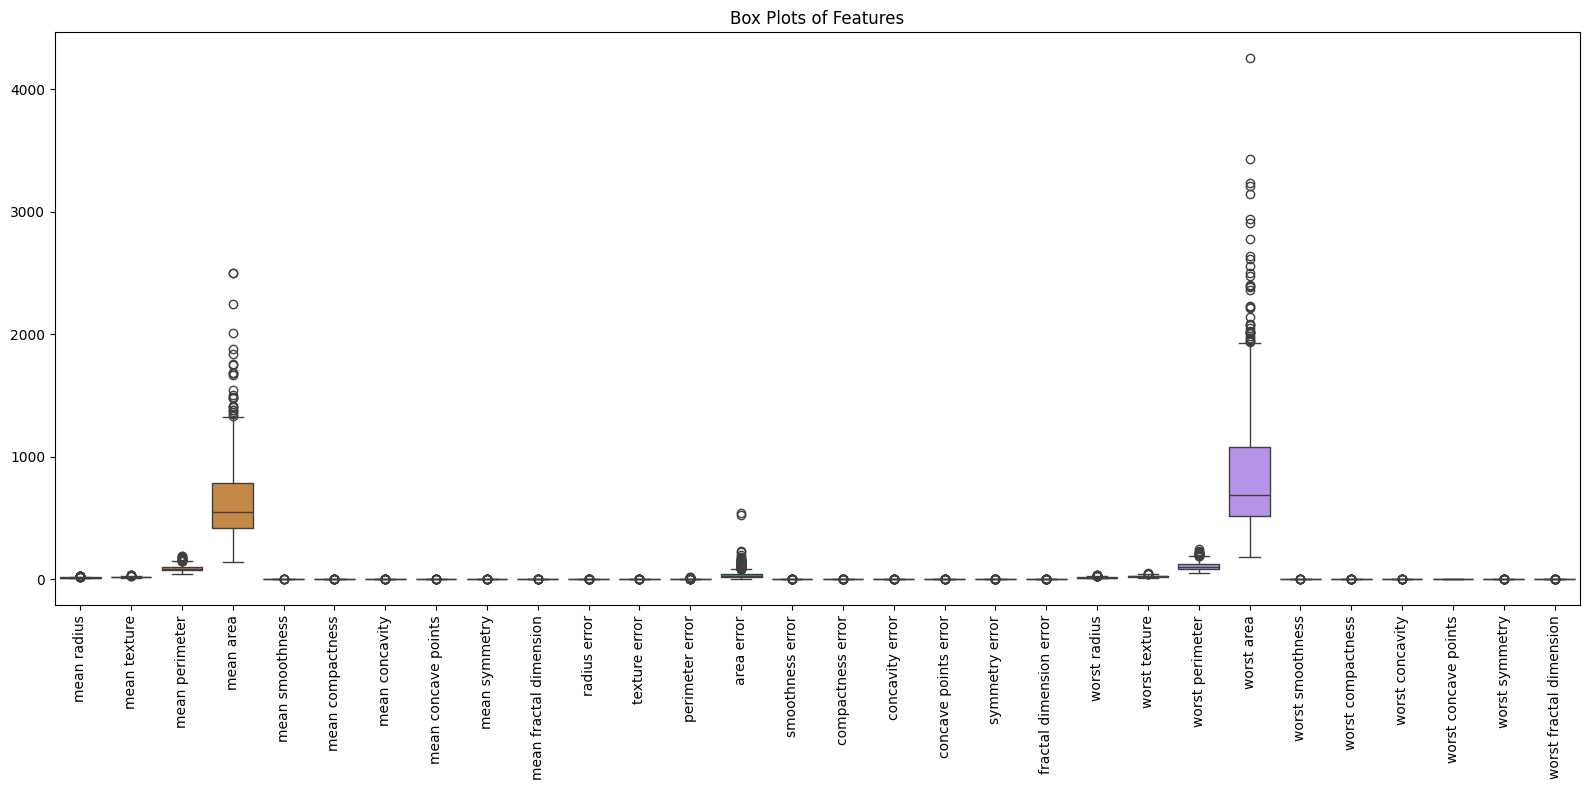

In [18]:
plt.figure(figsize=(16, 8))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.title("Box Plots of Features")
plt.tight_layout()
plt.show()

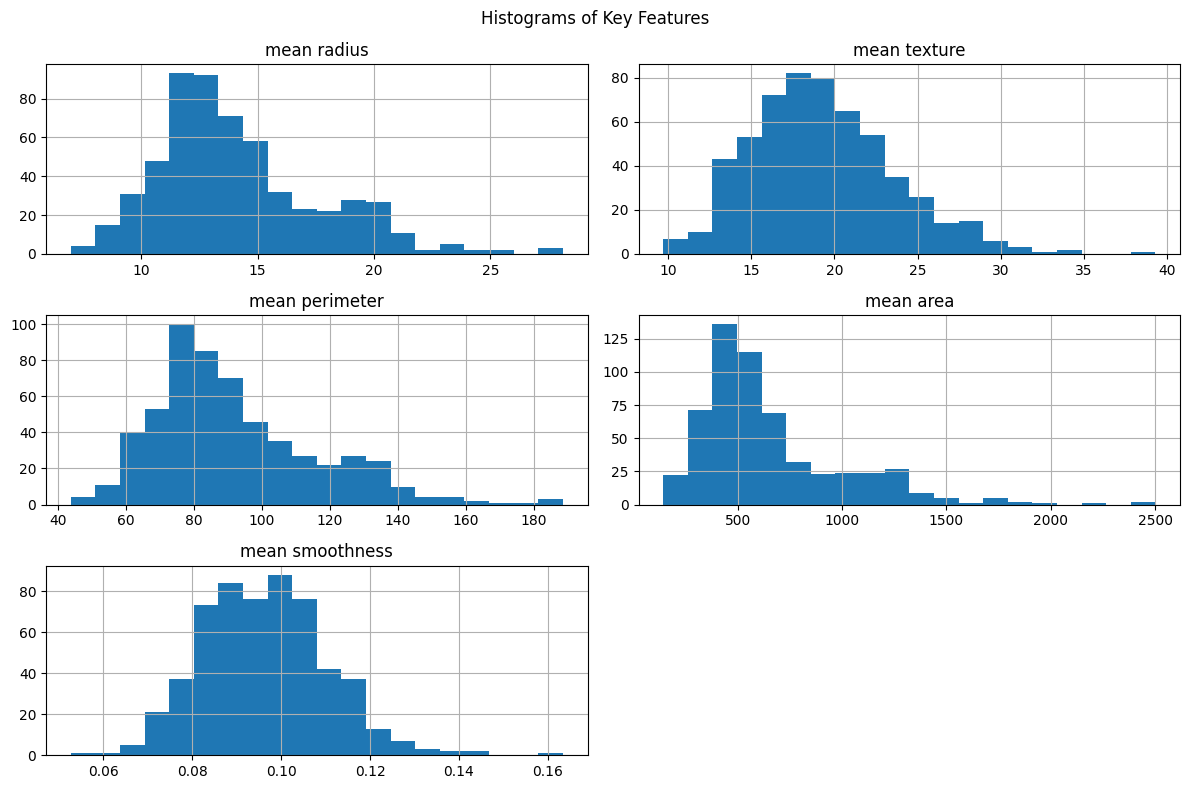

In [19]:
key_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

X[key_features].hist(figsize=(12, 8), bins=20)

plt.suptitle("Histograms of Key Features")
plt.tight_layout()
plt.show()

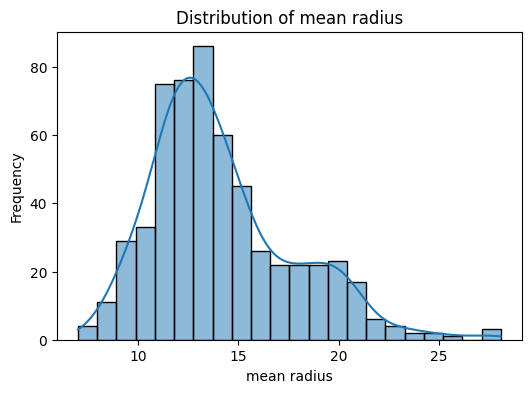

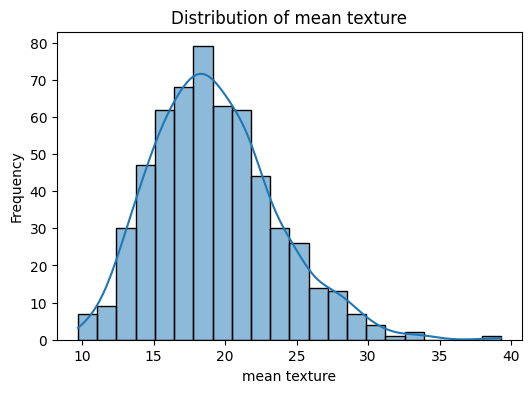

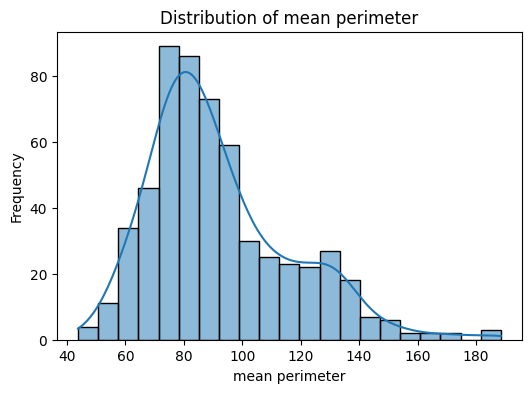

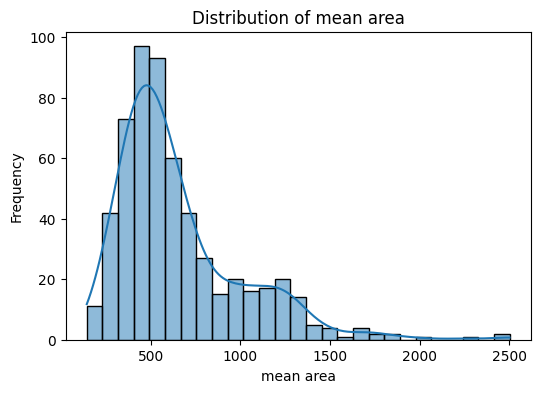

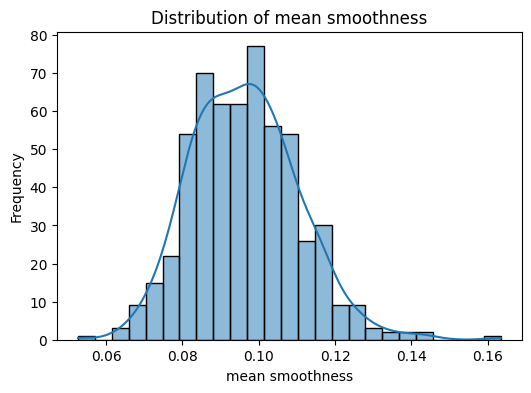

In [20]:
for feature in key_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(X[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

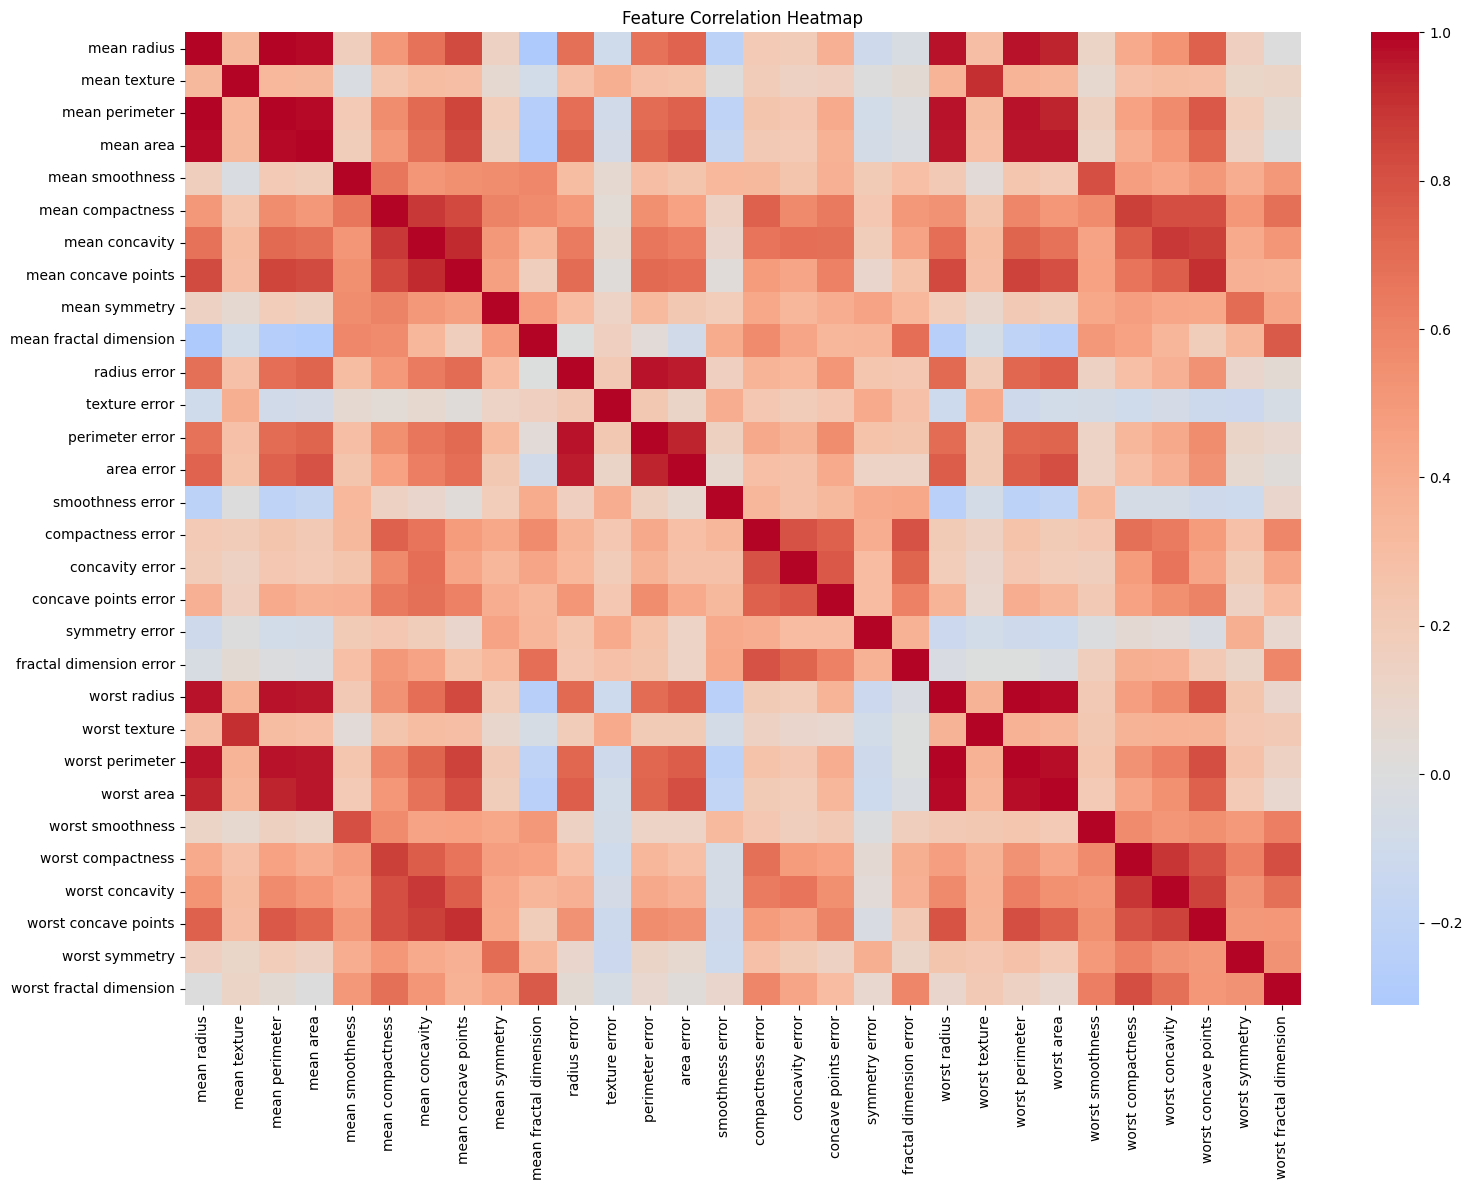

In [21]:
plt.figure(figsize=(16, 12))

correlation_matrix = X.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [22]:
print(df["Outcome"].value_counts())

Outcome
1    357
0    212
Name: count, dtype: int64


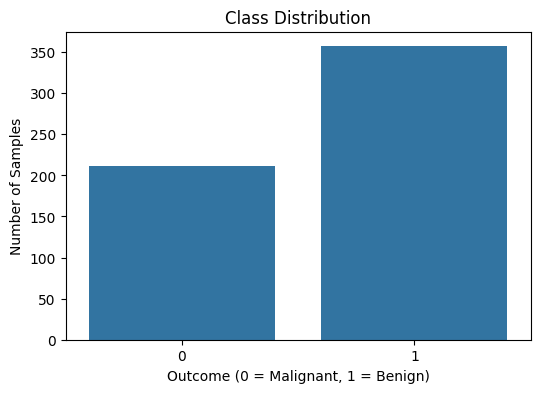

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Outcome", data=df)

plt.title("Class Distribution")
plt.xlabel("Outcome (0 = Malignant, 1 = Benign)")
plt.ylabel("Number of Samples")

plt.show()

In [24]:
class_percentages = df["Outcome"].value_counts(normalize=True) * 100

print(class_percentages)

Outcome
1    62.741652
0    37.258348
Name: proportion, dtype: float64


In [25]:
y = df["Outcome"]

print(y.value_counts())

Outcome
1    357
0    212
Name: count, dtype: int64


In [26]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [28]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training class distribution:
Outcome
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Testing class distribution:
Outcome
1    0.631579
0    0.368421
Name: proportion, dtype: float64


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [31]:
y_pred = model.predict(X_test_scaled)

# Probability of class 1 (benign)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [32]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[41  1]
 [ 1 71]]


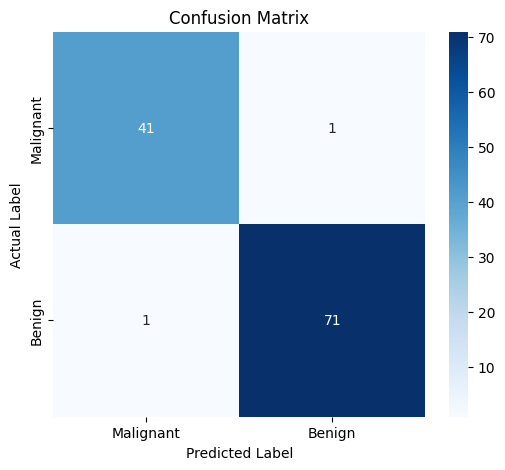

In [34]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC:", auc_score)

AUC: 0.9953703703703703


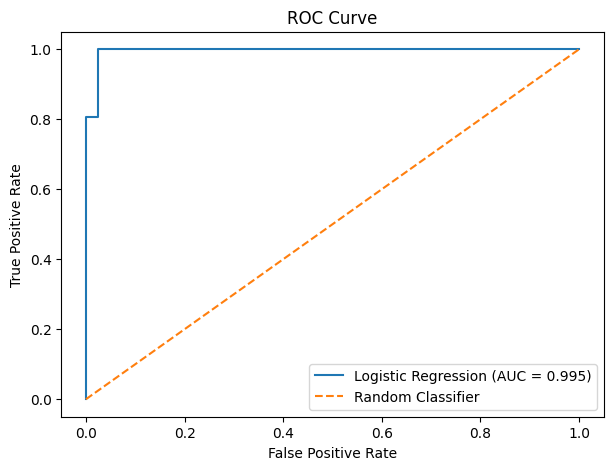

In [36]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()